In [1]:
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.signal import resample
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns

In [2]:
def separate_sides(pi_data):
    left_df = pi_data[pi_data['foot'] == 'left']
    right_df = pi_data[pi_data['foot'] == 'right']

    left_data = pi_reshape(left_df)
    right_data = pi_reshape(right_df)
    return left_data, right_data

In [3]:
def separate_sides(pi_data):
    left_df = pi_data[pi_data['foot'] == 'left']
    right_df = pi_data[pi_data['foot'] == 'right']

    left_data = pi_reshape(left_df)
    right_data = pi_reshape(right_df)
    return left_data, right_data

In [9]:
def pi_reshape(side_df):
    """
    reshapes continuous df to 3D array [31 x 11 x number of frames]
    :param side_df: continuous df
    :return: 3d array [31 x 11 x number of frames]
    """
    frames = side_df['frame'].unique()
    side_array = np.empty([31,11,frames[-1]])
    for i in frames:
        side_array[:, :, i - 1] = side_df.loc[side_df['frame'] == i, '0':'10'].values
    return side_array

In [4]:
def pi_force(array3):
    return np.sum(np.sum(array3, axis=0), axis=0)

In [5]:
# IC & TO detection
def pi_step_segmentation(force_left, force_right, sampling_rate_pi):
    """
    :param force_left:
    :param force_right:
    :param sampling_rate_pi:
    :return:
    """
    IC_left = pi_ic(force_left, sampling_rate_pi)
    IC_right = pi_ic(force_right, sampling_rate_pi)
    TO_left = pi_to(force_left, IC_left)
    TO_right = pi_to(force_right, IC_right)
    events_dict = {'IC_left': np.array(IC_left[:-1]),
              'IC_right': np.array(IC_right[:-1]),
              'TO_left': np.array(TO_left),
              'TO_right': np.array(TO_right)
    }
    return events_dict

def pi_ic(force_side, sampling_rate):
    # calculate rate of force development (1st derivative of force)
    rfd = np.diff(force_side, n=1)*sampling_rate   # unit N/s

    # find where rfd > 1500 N/s based on Seiberl et al. (2018)
    rfd_1500 = np.where(rfd > 1500)[0]

    # first IC is when rfd first exceeds 1500 N/s
    IC_side = [rfd_1500[0]]

    # next IC of the same side has to be at least 250 ms away (fs/4)
    for i in range(1, len(rfd_1500)):
        if rfd_1500[i] - rfd_1500[i - 1] > sampling_rate / 4:
            IC_side.append(rfd_1500[i])
    IC_side=np.array(IC_side, dtype=int)
    return IC_side

def pi_to(force_side, IC_side):
    # filter force data (below 20 N threshold --> 0)
    force_side[force_side < 20] = 0
    TO_side=[]

    # loop to find Toe Off after respective IC
    # force = 0 for the first time after IC
    # clip before last IC (there might not be a toe off after)
    for IC in IC_side[:-1]:
        TO_side.extend(np.argwhere(force_side[IC+1:] == 0)[0] + IC+1)
    return TO_side

In [6]:
def pi_temporal_parameters(pi_events_dict, sampling_rate_pi):
    """
    calculates Ground Contact Time, Flight Time, Stride Time
    :param pi_events_dict: Dict containing all IC and TO events
    :param sampling_rate_pi: sampling rate fs
    :return temp_params_df: df with GCT, Flight T., Stride T., Side for all Steps
    """
    side = []
    gct = []
    st = []
    ft_left_off = []
    ft_right_off = []
    ft = []

    st_left = np.diff(pi_events_dict['IC_left']/sampling_rate_pi, n=1)
    st_right = np.diff(pi_events_dict['IC_right']/sampling_rate_pi, n=1)
    gct_left = (pi_events_dict['TO_left']-pi_events_dict['IC_left'])/sampling_rate_pi
    gct_right = (pi_events_dict['TO_right']-pi_events_dict['IC_right'])/sampling_rate_pi

    # 1st step left or right?
    if pi_events_dict['IC_left'][0] < pi_events_dict['IC_right'][0]:
        order = ['left', 'right']
        # TODO: somehow not working yet...
        for i in range(len(pi_events_dict['TO_left'])-1):
            ft_left_off.append((pi_events_dict['IC_right'][i]-pi_events_dict['TO_left'][i]) / sampling_rate_pi)
        for i in range(len(pi_events_dict['TO_right'])):
            ft_right_off.append((pi_events_dict['IC_left'][i+1] - pi_events_dict['TO_right'][i]) / sampling_rate_pi)


          #  ft_right_off.append((pi_events_dict['IC_left'][i+1]-pi_events_dict['TO_right'][i])/sampling_rate_pi)
          #  ft.append((pi_events_dict['IC_right'][i]-pi_events_dict['TO_left'][i])/sampling_rate_pi)
          #  ft.append((pi_events_dict['IC_right'][i] - pi_events_dict['TO_left'][i])/sampling_rate_pi)

  #  else:
     #   None

    IC_left = pi_events_dict['IC_left']
    temp_params_df = None
    return temp_params_df

In [7]:
df = pd.read_csv(r'D:\Salzburg\julian_cutting_wedges\221122_pi_test\pi_hop1.csv')

In [16]:
left, right = separate_sides(df)
force_left = pi_force(left)
force_right = pi_force(right)

In [40]:
force_left[force_left < 120] = 0
force_right[force_right < 140] = 0

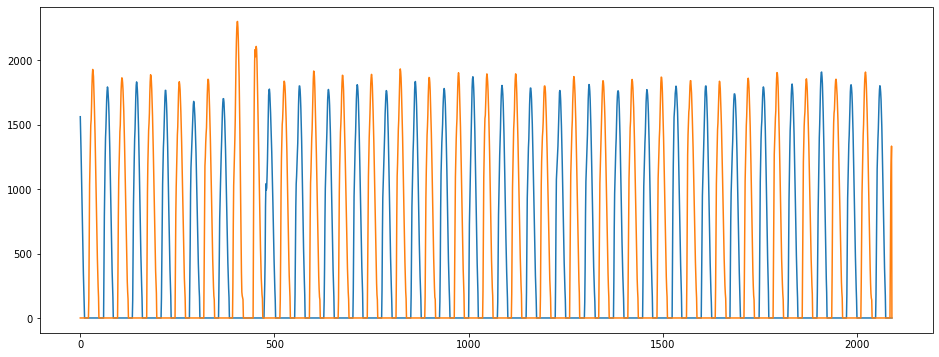

In [41]:
plt.figure(figsize=(16, 6))
plt.plot(force_left)
plt.plot(force_right)
#plt.ylim(0,200)

In [42]:
events_dict = pi_step_segmentation(force_left, force_right, 100)

In [43]:
events_dict

{'IC_left': array([  60,  134,  208,  281,  356,  473,  552,  627,  702,  776,  851,
         925, 1000, 1074, 1148, 1223, 1298, 1373, 1448, 1524, 1599, 1673,
        1748, 1822, 1897, 1973]),
 'IC_right': array([  21,   96,  171,  244,  318,  392,  445,  514,  590,  664,  739,
         813,  887,  963, 1036, 1110, 1184, 1260, 1335, 1410, 1485, 1561,
        1635, 1709, 1784, 1859, 1935, 2010]),
 'TO_left': array([  85,  160,  234,  308,  384,  503,  579,  654,  728,  803,  878,
         952, 1025, 1101, 1175, 1250, 1326, 1400, 1474, 1549, 1626, 1700,
        1773, 1848, 1923, 2000], dtype=int64),
 'TO_right': array([  48,  124,  197,  271,  346,  420,  470,  541,  618,  692,  766,
         840,  915,  989, 1063, 1137, 1212, 1286, 1362, 1437, 1512, 1588,
        1663, 1736, 1811, 1886, 1963, 2039], dtype=int64)}

In [54]:
IC = np.sort(np.concatenate([events_dict['IC_right'], events_dict['IC_left']]))[1:]

In [55]:
TO = np.sort(np.concatenate([events_dict['TO_right'], events_dict['TO_left']]))[:-1]

In [58]:
(IC-TO)/100

array([0.12, 0.11, 0.1 , 0.11, 0.11, 0.1 , 0.1 , 0.1 , 0.1 , 0.08, 0.25,
       0.03, 0.11, 0.11, 0.11, 0.09, 0.1 , 0.1 , 0.11, 0.1 , 0.1 , 0.11,
       0.09, 0.1 , 0.11, 0.11, 0.11, 0.11, 0.09, 0.11, 0.09, 0.11, 0.1 ,
       0.12, 0.09, 0.11, 0.1 , 0.11, 0.11, 0.12, 0.12, 0.11, 0.09, 0.1 ,
       0.09, 0.12, 0.11, 0.11, 0.11, 0.11, 0.12, 0.1 , 0.1 ])

In [60]:
if events_dict['IC_right'][0] < events_dict['IC_left'][0]:
    ft_left_off = (IC-TO)[::2]/100
    ft_right_off = (IC-TO)[1::2]/100

In [85]:
np.repeat(['flight_time', 'gct', 'stride'],2)

array(['flight_time', 'flight_time', 'gct', 'gct', 'stride', 'stride'],
      dtype='<U11')

In [86]:
cols = [np.repeat(['Stride Time', 'Stance Time [s]','Flight Time [s]'],2), np.tile(['left', 'right'], 3)]
cols
   

[array(['Stride Time', 'Stride Time', 'Stance Time [s]', 'Stance Time [s]',
        'Flight Time [s]', 'Flight Time [s]'], dtype='<U15'),
 array(['left', 'right', 'left', 'right', 'left', 'right'], dtype='<U5')]

<AxesSubplot:>

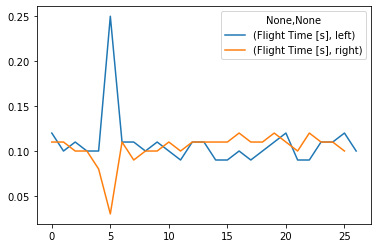

In [84]:
pd.DataFrame([ft_left_off, ft_right_off], index = cols).T.plot()

In [94]:
def pi_temporal_parameters(pi_events_dict, sampling_rate_pi):
    """
    calculates Ground Contact Time, Flight Time, Stride Time
    :param pi_events_dict: Dict containing all IC and TO events
    :param sampling_rate_pi: sampling rate fs
    :return temp_params_df: df with GCT, Flight T., Stride T., Side for all Steps
    """
    
    st_left = np.diff(pi_events_dict['IC_left']/sampling_rate_pi, n=1)
    st_right = np.diff(pi_events_dict['IC_right']/sampling_rate_pi, n=1)
    gct_left = (pi_events_dict['TO_left']-pi_events_dict['IC_left'])/sampling_rate_pi
    gct_right = (pi_events_dict['TO_right']-pi_events_dict['IC_right'])/sampling_rate_pi
    
    IC_all = np.sort(np.concatenate([pi_events_dict['IC_right'], pi_events_dict['IC_left']]))[1:]
    TO_all = np.sort(np.concatenate([events_dict['TO_right'], events_dict['TO_left']]))[:-1]
    ft = (IC_all - TO_all)/100
    if events_dict['IC_right'][0] < events_dict['IC_left'][0]:
        ft_right_off = (IC-TO)[::2]/100
        ft_left_off = (IC-TO)[1::2]/100
    else:
        ft_left_off = (IC-TO)[::2]/100
        ft_right_off = (IC-TO)[1::2]/100
    
    cols = [np.repeat(['Stride Time [s]', 'Stance Time [s]','Flight Time [s]'],2), np.tile(['left', 'right'], 3)]
    
    temp_params_df = pd.DataFrame([st_left, st_right, gct_left, gct_right, ft_left_off, ft_right_off], index = cols).T
    return temp_params_df

In [100]:
temp_df = pi_temporal_parameters(events_dict, 100)

<Figure size 1152x432 with 0 Axes>

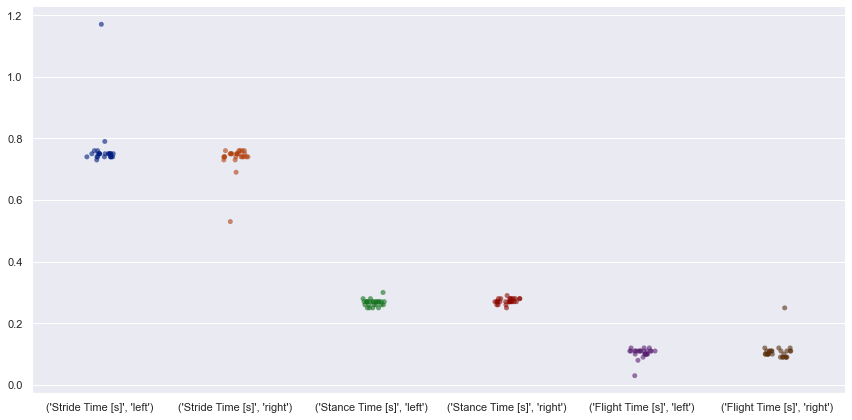

In [133]:
fig = plt.figure(figsize=(16, 6))
g=sns.catplot(data = temp_df, palette="dark", alpha=.6, height=6, aspect = 2)



In [111]:
temp_df.columns

MultiIndex([('Stride Time [s]',  'left'),
            ('Stride Time [s]', 'right'),
            ('Stance Time [s]',  'left'),
            ('Stance Time [s]', 'right'),
            ('Flight Time [s]',  'left'),
            ('Flight Time [s]', 'right')],
           )